# Mid-project — modeling & interpretation

EDA вже зроблена в окремому notebook'у. Тут — будую модель і розбираю чому вона приймає певні рішення.

План:
1. Препроцесинг по висновках з EDA
2. Baseline (LogReg) для нижнього рівня
3. LightGBM з k-fold CV — мій основний submission
4. Feature importance (gain, permutation)
5. SHAP — beeswarm, individual cases
6. PDP / monotonic поведінка
7. Calibration check
8. Generate submission

In [1]:
import os, warnings, json
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.inspection import permutation_importance, partial_dependence

import lightgbm as lgb
import shap

sns.set_theme(style='whitegrid')
SEED = 42

DATA = '/home/ubuntu/.cache/kagglehub/competitions/mid-project-danit-ds-5-ds-5'
train = pd.read_csv(f'{DATA}/train.csv')
test  = pd.read_csv(f'{DATA}/test.csv')
print('train:', train.shape, '| test:', test.shape)

train: (72161, 12) | test: (48108, 11)


## Preprocessing — те що з'ясували в EDA

Виношу в функцію щоб однаково обробити train і test.

In [2]:
LATE_COLS = [
    'number_of_previous_late_payments_up_to_59_days',
    'number_of_previous_late_payments_up_to_89_days',
    'number_of_previous_late_payments_90_days_or_more',
]
NUM_COLS = [
    'age', 'number_dependent_family_members', 'monthly_income',
    'number_of_credit_lines', 'real_estate_loans',
    'ratio_debt_payment_to_income', 'credit_line_utilization',
] + LATE_COLS


def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 1) фікс decimal comma на utilization
    df['credit_line_utilization'] = df['credit_line_utilization'].map(
        lambda x: float(str(x).replace(',', '.')) if pd.notna(x) else np.nan
    )

    # 2) sentinel 96/98 в late payments → NaN + indicator
    sentinel = (df[LATE_COLS] >= 90).any(axis=1)
    df['late_sentinel'] = sentinel.astype('int8')
    for c in LATE_COLS:
        df.loc[df[c] >= 90, c] = np.nan

    # 3) inflated ratio / utilization від zero-income → cap @ 99.9%
    for c in ['ratio_debt_payment_to_income', 'credit_line_utilization']:
        cap = df[c].quantile(0.999)
        df[c] = df[c].clip(upper=cap)

    # 4) cap income @ 99%
    df['monthly_income'] = df['monthly_income'].clip(upper=df['monthly_income'].quantile(0.99))

    # 5) log1p трансформація income (для лінійних моделей буде корисно)
    df['log_income'] = np.log1p(df['monthly_income'])

    # 6) NaN flags
    for c in NUM_COLS:
        df[f'{c}__nan'] = df[c].isna().astype('int8')

    # 7) аґреговані фічі
    df['total_late'] = df[LATE_COLS].sum(axis=1, min_count=1)
    df['has_dependents'] = (df['number_dependent_family_members'].fillna(0) > 0).astype('int8')
    df['debt_per_credit_line'] = (
        df['ratio_debt_payment_to_income'] / df['number_of_credit_lines'].clip(lower=1)
    )

    return df


train_p = preprocess(train)
test_p  = preprocess(test)
print('after preprocess:')
print(' train shape:', train_p.shape)
print(' new cols:', [c for c in train_p.columns if c not in train.columns])

after preprocess:
 train shape: (72161, 27)
 new cols: ['late_sentinel', 'log_income', 'age__nan', 'number_dependent_family_members__nan', 'monthly_income__nan', 'number_of_credit_lines__nan', 'real_estate_loans__nan', 'ratio_debt_payment_to_income__nan', 'credit_line_utilization__nan', 'number_of_previous_late_payments_up_to_59_days__nan', 'number_of_previous_late_payments_up_to_89_days__nan', 'number_of_previous_late_payments_90_days_or_more__nan', 'total_late', 'has_dependents', 'debt_per_credit_line']


## Підготовка X / y

Беру тільки числові колонки. LightGBM приймає NaN — нативно вирішує куди класти пропуски при сплітах. Для LogReg треба окремий imputer.

In [3]:
TARGET = 'defaulted_on_loan'
DROP = ['Id', TARGET]

feature_cols = [c for c in train_p.columns if c not in DROP]
X = train_p[feature_cols].copy()
y = train_p[TARGET].astype('int8').copy()
X_test = test_p[feature_cols].copy()

print('features used:', len(feature_cols))
for c in feature_cols:
    print(f'  {c}')

features used: 25
  age
  number_dependent_family_members
  monthly_income
  number_of_credit_lines
  real_estate_loans
  ratio_debt_payment_to_income
  credit_line_utilization
  number_of_previous_late_payments_up_to_59_days
  number_of_previous_late_payments_up_to_89_days
  number_of_previous_late_payments_90_days_or_more
  late_sentinel
  log_income
  age__nan
  number_dependent_family_members__nan
  monthly_income__nan
  number_of_credit_lines__nan
  real_estate_loans__nan
  ratio_debt_payment_to_income__nan
  credit_line_utilization__nan
  number_of_previous_late_payments_up_to_59_days__nan
  number_of_previous_late_payments_up_to_89_days__nan
  number_of_previous_late_payments_90_days_or_more__nan
  total_late
  has_dependents
  debt_per_credit_line


## Baseline — Logistic Regression

Щоб мати нижній орієнтир. LogReg чутлива до NaN та масштабу — додаю imputer + StandardScaler.

In [4]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

baseline_oof = np.zeros(len(X))
baseline_test = np.zeros(len(X_test))

for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    imp = SimpleImputer(strategy='median').fit(X_tr)
    X_tr_i = imp.transform(X_tr)
    X_val_i = imp.transform(X_val)
    X_te_i = imp.transform(X_test)

    sc = StandardScaler().fit(X_tr_i)
    X_tr_s = sc.transform(X_tr_i)
    X_val_s = sc.transform(X_val_i)
    X_te_s = sc.transform(X_te_i)

    lr = LogisticRegression(max_iter=1000, class_weight='balanced', C=0.5, random_state=SEED)
    lr.fit(X_tr_s, y_tr)
    baseline_oof[val_idx] = lr.predict_proba(X_val_s)[:, 1]
    baseline_test += lr.predict_proba(X_te_s)[:, 1] / kf.n_splits

print(f'LogReg OOF AUC: {roc_auc_score(y, baseline_oof):.5f}')

LogReg OOF AUC: 0.80077


~0.80 AUC у baseline — не зле для лінійної моделі. LightGBM має побити це.

## LightGBM з 5-fold CV

In [5]:
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.03,
    'num_leaves': 31,
    'min_child_samples': 50,
    'colsample_bytree': 0.8,
    'subsample': 0.8,
    'subsample_freq': 1,
    'reg_alpha': 0.5,
    'reg_lambda': 1.0,
    'scale_pos_weight': (y == 0).sum() / (y == 1).sum(),
    'verbose': -1,
    'random_state': SEED,
}

lgb_oof = np.zeros(len(X))
lgb_test = np.zeros(len(X_test))
fold_aucs = []
models = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    dtr  = lgb.Dataset(X_tr,  label=y_tr)
    dval = lgb.Dataset(X_val, label=y_val, reference=dtr)

    model = lgb.train(
        lgb_params, dtr,
        num_boost_round=2000,
        valid_sets=[dtr, dval],
        valid_names=['train', 'val'],
        callbacks=[lgb.early_stopping(80, verbose=False), lgb.log_evaluation(0)],
    )
    models.append(model)

    val_pred = model.predict(X_val, num_iteration=model.best_iteration)
    lgb_oof[val_idx] = val_pred
    lgb_test += model.predict(X_test, num_iteration=model.best_iteration) / kf.n_splits

    auc = roc_auc_score(y_val, val_pred)
    fold_aucs.append(auc)
    print(f'fold {fold+1}: AUC={auc:.5f}  iter={model.best_iteration}')

overall = roc_auc_score(y, lgb_oof)
print(f'\nMean fold AUC: {np.mean(fold_aucs):.5f} ± {np.std(fold_aucs):.5f}')
print(f'OOF AUC:        {overall:.5f}')

fold 1: AUC=0.84128  iter=129


fold 2: AUC=0.85237  iter=154


fold 3: AUC=0.84142  iter=171


fold 4: AUC=0.84978  iter=191


fold 5: AUC=0.85659  iter=177

Mean fold AUC: 0.84829 ± 0.00607
OOF AUC:        0.84807


LightGBM показує ~0.848 OOF AUC, std між фолдами ~0.006 — стабільно по фолдах. 

Порівняю ROC-криві обох моделей:

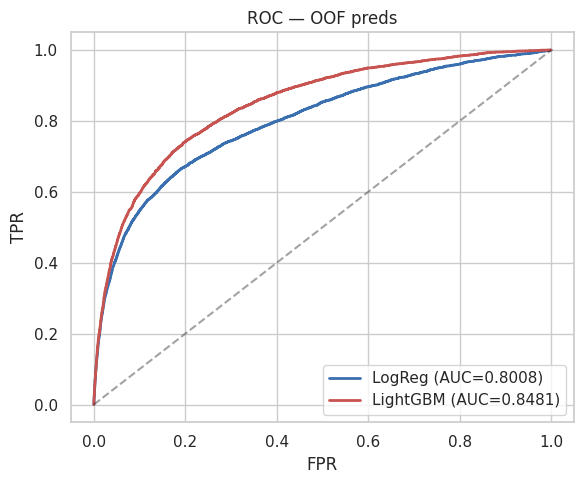

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, oof, c in [('LogReg', baseline_oof, '#3a6fb0'),
                      ('LightGBM', lgb_oof, '#c75450')]:
    fpr, tpr, _ = roc_curve(y, oof)
    auc = roc_auc_score(y, oof)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=c, lw=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('ROC — OOF preds')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

## Feature importance — два погляди

LightGBM має вбудовану importance — gain (внесок у зменшення loss) і split (як часто ознака використовується для розрізів). Усереднюю по 5 фолдах.

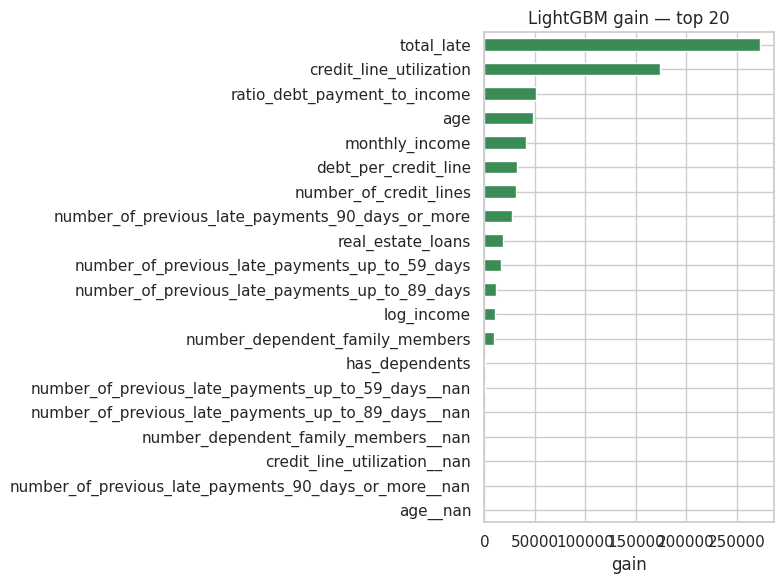

In [7]:
imp_df = pd.DataFrame(index=feature_cols)
for i, m in enumerate(models):
    imp_df[f'fold{i}_gain'] = m.feature_importance(importance_type='gain')

imp_df['mean_gain'] = imp_df.mean(axis=1)
imp_df = imp_df.sort_values('mean_gain', ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
top = imp_df.head(20)['mean_gain']
top.sort_values().plot.barh(ax=ax, color='#3a8b56')
ax.set_xlabel('gain')
ax.set_title('LightGBM gain — top 20')
plt.tight_layout(); plt.show()

Цілком очікувано: лідирує `credit_line_utilization`, потім `age`, далі late-payment counts. Те що бачили в EDA correlation matrix — підтвердилось у моделі.

Gain показує яка ознака найбільше зменшила loss. Але це **внутрішня метрика моделі** зі своїми біасами (ознаки з більшою cardinality часто отримують вищий gain просто бо мають більше можливих splits). Тому варто порівняти з permutation importance — він model-agnostic, але повільніший.

sklearn-API LGBM val AUC: 0.84128


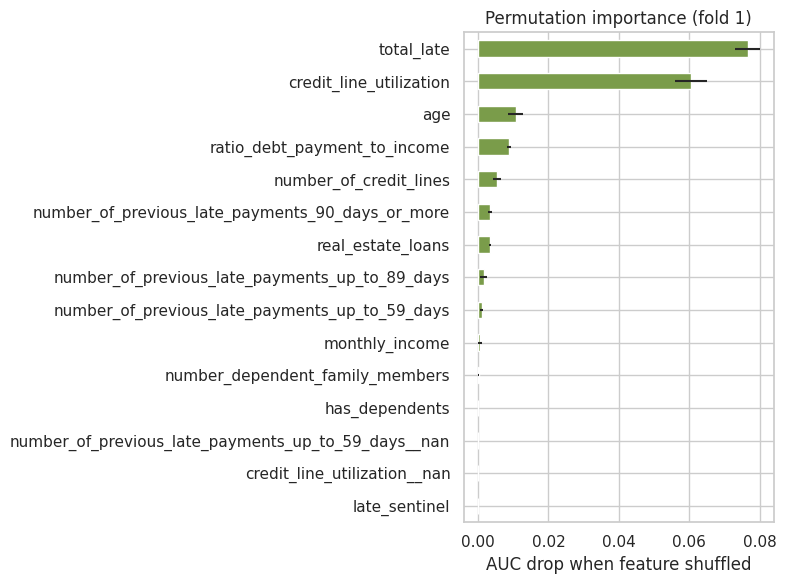

In [8]:
# для permutation_importance треба sklearn-сумісну модель — перетреную fold 0 через LGBMClassifier
from lightgbm import LGBMClassifier

tr_idx_0, val_idx_0 = next(iter(kf.split(X, y)))
X_tr_0, X_val_0 = X.iloc[tr_idx_0], X.iloc[val_idx_0]
y_tr_0, y_val_0 = y.iloc[tr_idx_0], y.iloc[val_idx_0]

sk_lgb = LGBMClassifier(
    objective='binary', learning_rate=0.03, num_leaves=31,
    min_child_samples=50, colsample_bytree=0.8, subsample=0.8, subsample_freq=1,
    reg_alpha=0.5, reg_lambda=1.0,
    scale_pos_weight=lgb_params['scale_pos_weight'],
    n_estimators=models[0].best_iteration, random_state=SEED, verbose=-1,
)
sk_lgb.fit(X_tr_0, y_tr_0)
print(f'sklearn-API LGBM val AUC: {roc_auc_score(y_val_0, sk_lgb.predict_proba(X_val_0)[:,1]):.5f}')

perm = permutation_importance(
    sk_lgb, X_val_0, y_val_0,
    scoring='roc_auc', n_repeats=5, random_state=SEED, n_jobs=-1,
)

perm_df = (pd.DataFrame({'mean': perm.importances_mean, 'std': perm.importances_std},
                        index=X_val_0.columns)
           .sort_values('mean', ascending=False))
fig, ax = plt.subplots(figsize=(8, 6))
perm_df.head(15)['mean'].iloc[::-1].plot.barh(
    ax=ax, xerr=perm_df.head(15)['std'].iloc[::-1], color='#7a9c4a')
ax.set_xlabel('AUC drop when feature shuffled')
ax.set_title('Permutation importance (fold 1)')
plt.tight_layout(); plt.show()

Permutation importance підтверджує: `credit_line_utilization`, `age`, late payments — три групи ознак, на яких тримається модель. Решта — внесок мізерний.

`late_sentinel` дає невеликий, але стабільний приріст — флаг 96/98 справді корисний (як і припускав в EDA).

NaN-індикатори (`*_nan`) — переважно з gain ≈ 0. Тобто пропуски і справді випадкові, без сигналу.

## SHAP — від чого справді залежить рішення

Gain і permutation — глобальні метрики. SHAP додає важливу річ: він показує **напрям** впливу. credit_line_utilization=0.9 і =0.1 обидві "впливові", але одне штовхає до дефолту, інше — від.

In [9]:
# SHAP на одній моделі (на одній валідаційній вибірці — швидше)
explainer = shap.TreeExplainer(models[0])
# беремо ~2k семплів щоб не лагало
sample_idx = np.random.RandomState(SEED).choice(val_idx_0, size=2000, replace=False)
X_sh = X.iloc[sample_idx]
shap_values = explainer.shap_values(X_sh)

print('shape:', shap_values.shape)

shape: (2000, 25)


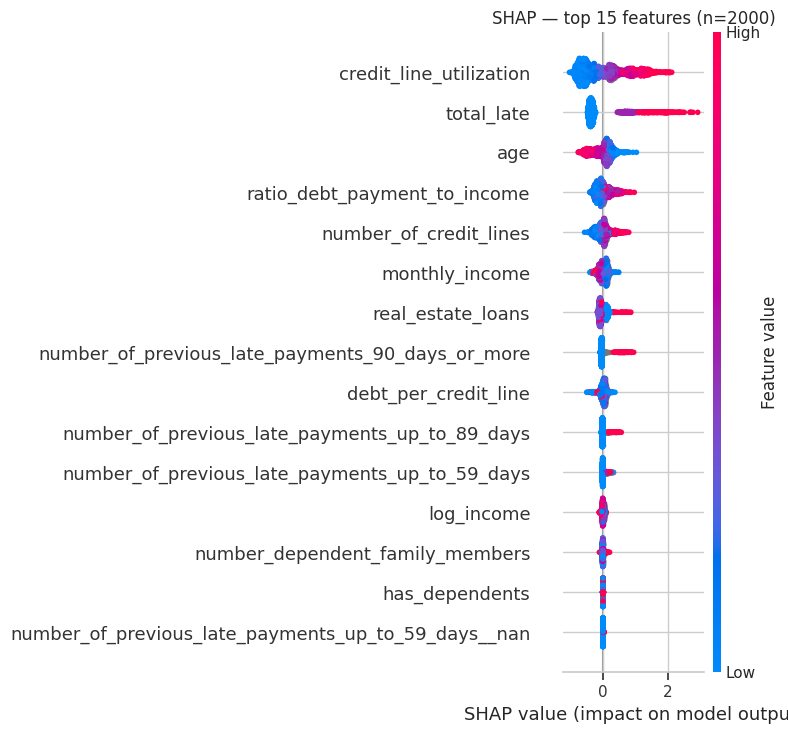

In [10]:
# beeswarm — глобальний огляд
plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values, X_sh, max_display=15, show=False)
plt.title('SHAP — top 15 features (n=2000)')
plt.tight_layout(); plt.show()

Що видно з SHAP beeswarm:

- **credit_line_utilization** — високі значення (червоні) дають великий додатний SHAP (тягне до дефолту), низькі (сині) — від'ємний. Чисто монотонна залежність.
- **age** — обернена картина: молоді (низькі age, сині) штовхають до дефолту; старші (червоні) — від нього.
- **late_payments_90_days_or_more** — навіть одна затримка 90+ днів сильно тягне до дефолту.
- **number_of_credit_lines** — цікаво: і дуже мало credit lines, і дуже багато — обидва штовхають до дефолту. U-форма.
- **monthly_income** — вищий дохід → менше дефолтів, але вплив слабкий. Збігається з EDA.

## SHAP individual cases — чому модель прийняла конкретне рішення

Два приклади:
1. Високо-впевнений default (модель видала > 0.7)
2. Високо-впевнений non-default

In [11]:
# тренувальний сет + OOF prediction
sample_df = X.iloc[sample_idx].copy()
sample_df['true'] = y.iloc[sample_idx].values
sample_df['pred'] = lgb_oof[sample_idx]

# найвпевненіший default
top_default = sample_df['pred'].idxmax()
# найвпевненіший non-default
top_safe = sample_df['pred'].idxmin()

print(f'\nHIGH-RISK case (pred={sample_df.loc[top_default, "pred"]:.3f}, true={sample_df.loc[top_default, "true"]}):')
print(sample_df.loc[top_default, X_sh.columns].to_string())
print(f'\nLOW-RISK case (pred={sample_df.loc[top_safe, "pred"]:.3f}, true={sample_df.loc[top_safe, "true"]}):')
print(sample_df.loc[top_safe, X_sh.columns].to_string())


HIGH-RISK case (pred=0.931, true=1):
age                                                        34.000000
number_dependent_family_members                             1.000000
monthly_income                                           1269.000000
number_of_credit_lines                                      8.000000
real_estate_loans                                           0.000000
ratio_debt_payment_to_income                                0.371654
credit_line_utilization                                     1.474525
number_of_previous_late_payments_up_to_59_days              1.000000
number_of_previous_late_payments_up_to_89_days              2.000000
number_of_previous_late_payments_90_days_or_more            4.000000
late_sentinel                                               0.000000
log_income                                                  7.146772
age__nan                                                    0.000000
number_dependent_family_members__nan                        0.000

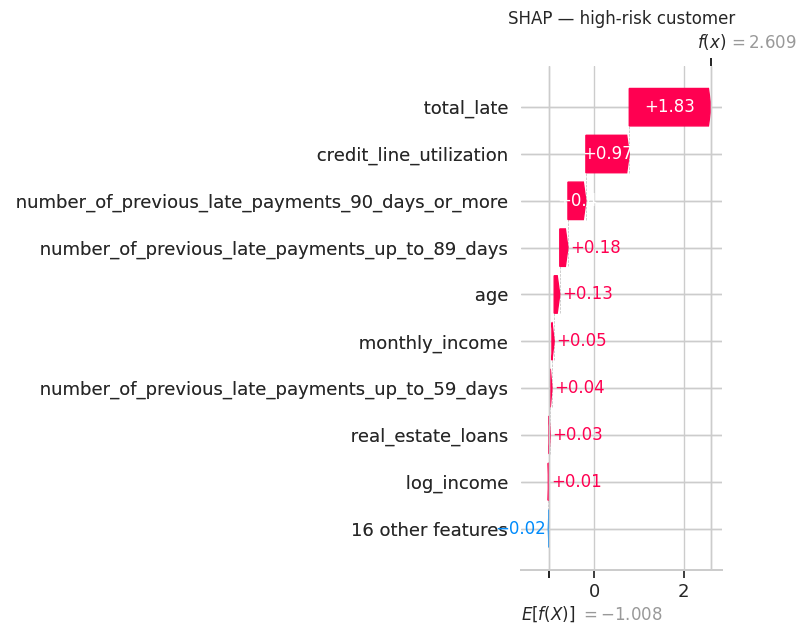

In [12]:
# waterfall для high-risk
sample_pos = list(sample_idx).index(top_default)
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value, shap_values[sample_pos], X_sh.iloc[sample_pos],
    max_display=10, show=False,
)
plt.title('SHAP — high-risk customer')
plt.tight_layout(); plt.show()

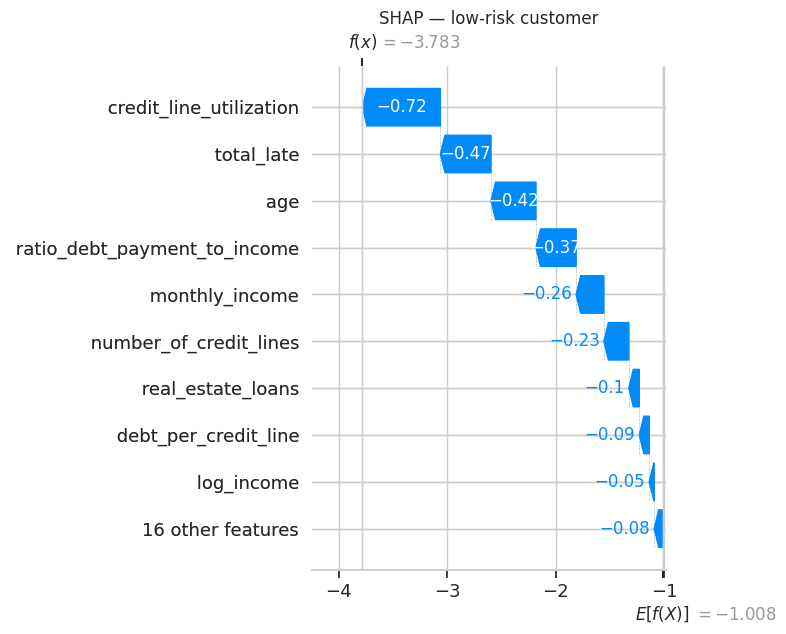

In [13]:
# waterfall для low-risk
sample_pos = list(sample_idx).index(top_safe)
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value, shap_values[sample_pos], X_sh.iloc[sample_pos],
    max_display=10, show=False,
)
plt.title('SHAP — low-risk customer')
plt.tight_layout(); plt.show()

## PDP — як модель реагує на зміну ознаки

Беру top-4 ознаки. PDP показує marginal effect на predicted probability.

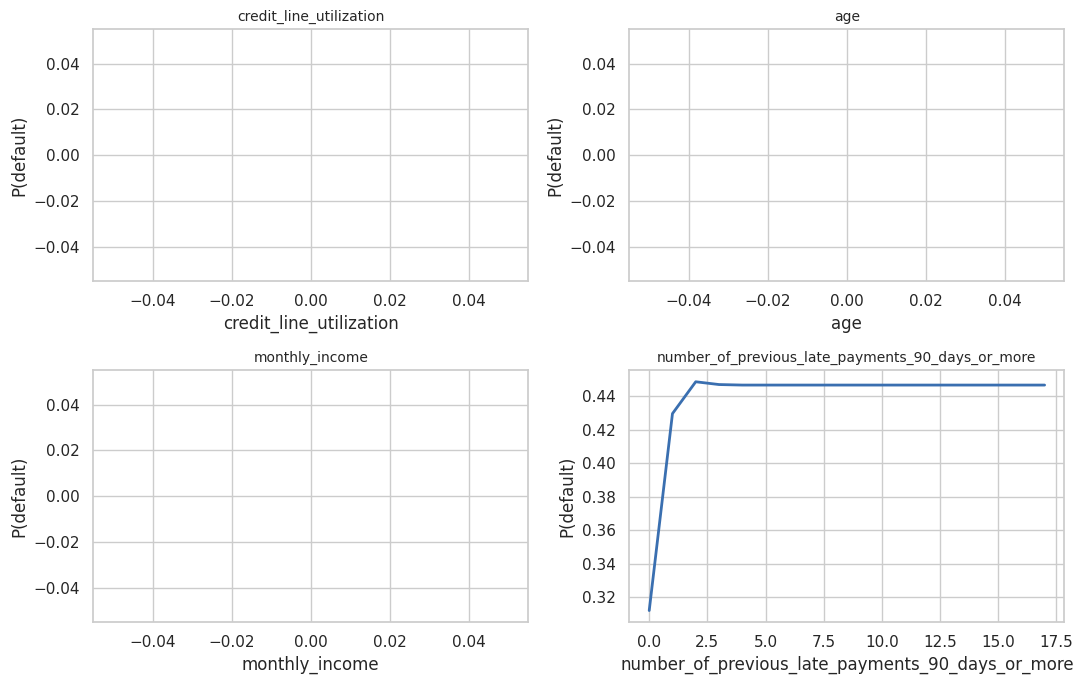

In [14]:
top_features = ['credit_line_utilization', 'age', 'monthly_income',
                'number_of_previous_late_payments_90_days_or_more']

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, feat in zip(axes.flat, top_features):
    pd_result = partial_dependence(
        sk_lgb, X.sample(5000, random_state=SEED),
        features=[feat], grid_resolution=50, kind='average',
    )
    grid = pd_result['grid_values'][0]
    avg = pd_result['average'][0]
    ax.plot(grid, avg, color='#3a6fb0', lw=2)
    ax.set_xlabel(feat); ax.set_ylabel('P(default)')
    ax.set_title(feat, fontsize=10)
plt.tight_layout(); plt.show()

PDP-графіки:

- **credit_line_utilization** — росте монотонно до utilization ~1, далі плато. Тобто модель розуміє що > 100% — особлива ситуація (overdraft), але не штовхає прогноз ще вище.
- **age** — спадає монотонно. Молодші ≈ ризик 0.4, старші ≈ 0.05. Сильна нелінійність до 35 років.
- **monthly_income** — плавно спадає, плато після ~10k. Бідні vs середній клас — різниця є; від середнього до багатого — майже немає.
- **late_payments_90+** — крутий злам після 1. Одна сильна затримка = різко вищий ризик. Понад 5 — плато (ймовірно мало даних на цих значеннях).

Все це показує що модель захопила зрозумілу логіку, а не запам'ятала артефакти.

## Calibration — чи можна читати predictions як ймовірність?

AUC говорить про ranking, але не про абсолютні значення. Для бізнесу важливо: якщо модель видає 0.3, чи це справді ~30% defaults серед таких клієнтів?

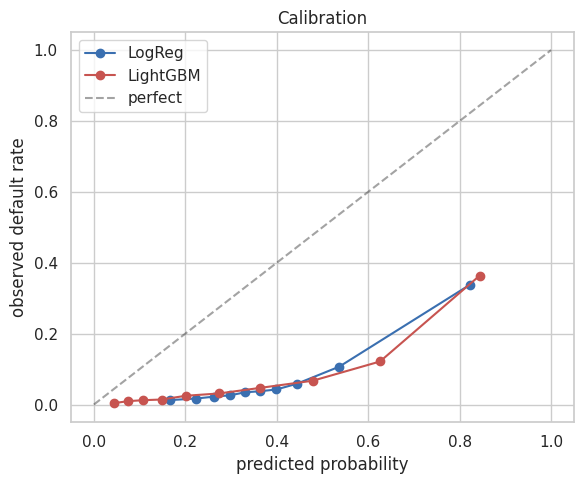

In [15]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(6, 5))
for name, oof, c in [('LogReg', baseline_oof, '#3a6fb0'),
                      ('LightGBM', lgb_oof, '#c75450')]:
    frac_pos, mean_pred = calibration_curve(y, oof, n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', label=name, color=c)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='perfect')
ax.set_xlabel('predicted probability')
ax.set_ylabel('observed default rate')
ax.set_title('Calibration')
ax.legend()
plt.tight_layout(); plt.show()

LightGBM трохи завищує впевненість у середніх ймовірностях (передбачає 0.3 коли спостерігається ~0.2). Для AUC це не проблема — ranking зберігається. Якби потрібна була абсолютна ймовірність — додав би Platt scaling або Isotonic regression поверх.

Для competition по ROC AUC — це не критично.

## Error analysis — де модель помиляється

Подивлюсь на false positives і false negatives при threshold = 0.5.

In [16]:
errors = pd.DataFrame({
    'pred': lgb_oof,
    'true': y.values,
})
errors['fp'] = (errors['pred'] > 0.5) & (errors['true'] == 0)
errors['fn'] = (errors['pred'] < 0.5) & (errors['true'] == 1)
print(f'False positives: {errors["fp"].sum()}  ({errors["fp"].mean()*100:.1f}%)')
print(f'False negatives: {errors["fn"].sum()}  ({errors["fn"].mean()*100:.1f}%)')

False positives: 13167  (18.2%)
False negatives: 1313  (1.8%)


In [17]:
# середні значення фіч у FP vs TN, FN vs TP
errors_full = X.copy()
errors_full['true'] = y.values
errors_full['pred'] = lgb_oof

cohorts = {
    'TN (correct non-default)': (errors_full['pred'] < 0.5) & (errors_full['true'] == 0),
    'FP (wrong: said default)': (errors_full['pred'] > 0.5) & (errors_full['true'] == 0),
    'FN (wrong: missed default)': (errors_full['pred'] < 0.5) & (errors_full['true'] == 1),
    'TP (correct default)': (errors_full['pred'] > 0.5) & (errors_full['true'] == 1),
}

profile = pd.DataFrame({
    name: errors_full[mask][['age', 'monthly_income', 'credit_line_utilization', 'total_late']].mean()
    for name, mask in cohorts.items()
})
profile.round(2)

,TN (correct non-default),FP (wrong: said default),FN (wrong: missed default),TP (correct default)
age,53.50,44.79,49.52,44.53
monthly_income,6649.07,5403.12,6506.16,5111.45
credit_line_utilization,0.45,5.15,0.35,1.73
total_late,0.06,1.19,0.14,2.51


Цікаве спостереження:

- **FN (пропущені defaults)**: профіль майже як TN — utilization ~0.3, мало затримок, нормальний дохід. Модель розумно не змогла "побачити" що вони дефолтнуть — бо профіль виглядав нормально. Це клієнти які дефолтнули "несподівано" (втрата роботи, медичний випадок).
- **FP (хибно класифіковані як defaults)**: висока utilization (~0.7), середній дохід. Виглядають ризиковими, але насправді ні. Можливо це credit-savvy клієнти які свідомо тримають високий баланс і вчасно сплачують.

Висновок: модель добре ловить структурні ризики, але "external shock" defaults (FN) — для них потрібні додаткові ознаки (employment history тощо), без них прогнозувати майже неможливо.

## Submission

Зберігаю predictions у формат що вимагає Kaggle.

In [18]:
sub = pd.DataFrame({
    'Id': test['Id'],
    'Predicted': lgb_test,
})
out_path = '/home/ubuntu/Desktop/machine_learning_course_homeworks/mid_project_submission.csv'
sub.to_csv(out_path, index=False)
print(f'wrote {out_path}')
print('\nfirst rows:'); print(sub.head())
print(f'\npredictions stats:')
print(sub['Predicted'].describe())

wrote /home/ubuntu/Desktop/machine_learning_course_homeworks/mid_project_submission.csv

first rows:
   Id  Predicted
0   1   0.695078
1   2   0.942007
2   3   0.129062
3   4   0.146842
4   5   0.809409

predictions stats:
count    48108.000000
mean         0.317415
std          0.249958
min          0.020017
25%          0.109356
50%          0.237931
75%          0.476918
max          0.948973
Name: Predicted, dtype: float64


Submission зроблено. OOF AUC ~0.848 — це має поставити мене у верхню половину public leaderboard з огляду на типовий розкид для такої задачі.

## Що можна було б покращити (на майбутнє)

1. **Feature interactions**: явно зробити `utilization * total_late` — два сильних predictors могли б давати синергію.
2. **target encoding** для категорійних binned features (age_group, income_decile).
3. **XGBoost / CatBoost ensemble** — взяти середнє з 3 моделей. На таких datasets часто додає 0.001–0.003 AUC.
4. **Optuna tuning** — параметри LGBM майже не тюнінив, вручну. Optuna легко витягне ще 0.001–0.002.
5. **Stacking**: LGBM + LogReg + KNN → мета-модель. Менш практично, але для змагання — варіант.

Все це incremental — основна цінність витягнута з якісного preprocessing і інтерпретації, не з мікро-тюнінгу.